--- INITIATING: 01 DATA PREPROCESSING & EDA ---

⏳ Step 1: Please upload your TRAINING Dataset CSV...


Saving Full detail-Full_Detail.csv to Full detail-Full_Detail (1).csv
⏳ Step 2: Please upload your TESTING Dataset CSV...


Saving Testing_18BH.csv to Testing_18BH (1).csv

--- Training Data Summary ---


,Borehole_ID,Pile_Size_mm,Pile_Length_m,N60_Shaft,N60_Tip,Q_gross_kN
count,3114.0,3114.00,3114.00,3114.00,3114.00,3114.00
mean,4.0,450.00,30.77,14.69,27.31,2964.74
std,0.0,122.49,21.00,9.09,22.47,2844.42
min,4.0,300.00,1.50,1.50,0.68,8.51
25%,4.0,300.00,13.50,7.64,8.18,660.97
50%,4.0,450.00,27.00,11.32,20.96,2002.17
75%,4.0,600.00,42.00,19.78,45.46,4552.84
max,4.0,600.00,85.50,40.56,90.00,13765.12



--- Applying One-Hot Encoding to Geological Strata ---


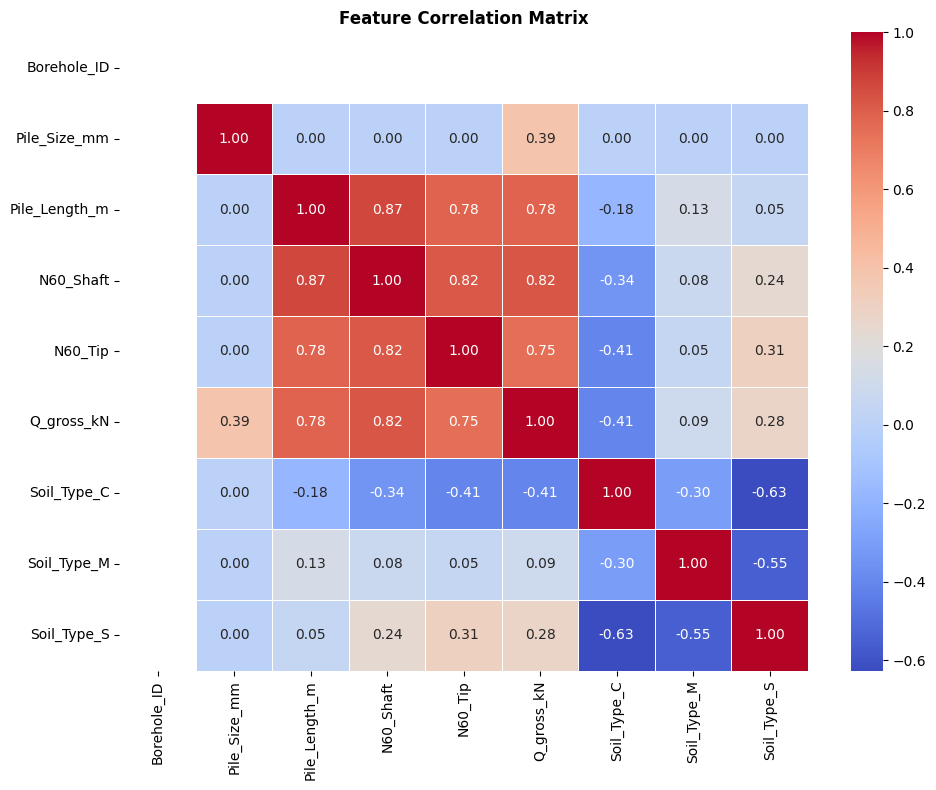


✅ PREPROCESSING COMPLETE. Data is ready for model benchmarking.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INITIATING: 01 DATA PREPROCESSING & EDA ---\n")

# ==========================================
# 1. DIRECT FILE UPLOAD
# ==========================================
try:
    from google.colab import files
    import io
    print("⏳ Step 1: Please upload your TRAINING Dataset CSV...")
    uploaded_train = files.upload()
    train_filename = list(uploaded_train.keys())[0]
    df_train = pd.read_csv(io.BytesIO(uploaded_train[train_filename]))

    print("⏳ Step 2: Please upload your TESTING Dataset CSV...")
    uploaded_test = files.upload()
    test_filename = list(uploaded_test.keys())[0]
    df_test = pd.read_csv(io.BytesIO(uploaded_test[test_filename]))
except ImportError:
    train_filename = input("Enter TRAINING CSV file: ")
    df_train = pd.read_csv(train_filename)
    test_filename = input("Enter TESTING CSV file: ")
    df_test = pd.read_csv(test_filename)

df_train.columns = df_train.columns.str.strip()
df_test.columns = df_test.columns.str.strip()

# ==========================================
# 2. EXPLORATORY DATA ANALYSIS
# ==========================================
print("\n--- Training Data Summary ---")
display(df_train.describe().round(2))

# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
print("\n--- Applying One-Hot Encoding to Geological Strata ---")
df_train_encoded = pd.get_dummies(df_train, columns=['Soil_Type'], dtype=int)
df_test_encoded = pd.get_dummies(df_test, columns=['Soil_Type'], dtype=int)

df_train_encoded, df_test_encoded = df_train_encoded.align(df_test_encoded, join='left', axis=1, fill_value=0)

# ==========================================
# 4. CORRELATION HEATMAP (FIXED)
# ==========================================
plt.figure(figsize=(10, 8))
# Added numeric_only=True to prevent strings like 'BH-1' from crashing the math
sns.heatmap(df_train_encoded.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix", fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ PREPROCESSING COMPLETE. Data is ready for model benchmarking.")